Required libraries

In [3]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib
import pickle
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

Load data

In [4]:
df = pd.read_csv("final_data.csv") 
df = df[['Review', 'Rating']]

print(df['Rating'].value_counts())

Rating
3.0    155613
4.0    148198
5.0    137475
1.0    126684
2.0    115643
Name: count, dtype: int64


Label encoding

In [5]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Rating'])
num_labels = len(label_encoder.classes_)

Train-Test-Split

In [6]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Review'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

Tokenization & Padding

In [7]:
max_vocab_size = 10000
max_seq_len = 128

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

train_padded = pad_sequences(train_sequences, maxlen=max_seq_len, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_seq_len, padding='post', truncating='post')

Tensorflow form data

In [8]:
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices((train_padded, train_labels)).shuffle(1000).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((test_padded, test_labels)).batch(batch_size)

Building LSTM Model

In [9]:
embedding_dim = 128
model_a = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_len),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_labels, activation='softmax')
])

In [10]:
model_a.summary()

model_a.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 128, 128)          1280000   
                                                                 
 bidirectional (Bidirection  (None, 128, 128)          98816     
 al)                                                             
                                                                 
 bidirectional_1 (Bidirecti  (None, 64)                41216     
 onal)                                                           
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 5)                 3

compute class weights

In [11]:
class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = {i: class_weights_values[i] for i in range(num_labels)}
print("Class weights:", class_weights)

Class weights: {0: 1.0792426021490522, 1: 1.1822731448954225, 2: 0.8786087235922564, 3: 0.9225695440206482, 4: 0.9945262775050009}


Train model

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model_a.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20


17091/17091 [==============================] - 1315s 77ms/step - loss: 1.0918 - accuracy: 0.5150 - val_loss: 1.0344 - val_accuracy: 0.5419
Epoch 2/20
17091/17091 [==============================] - 1299s 76ms/step - loss: 1.0195 - accuracy: 0.5506 - val_loss: 1.0183 - val_accuracy: 0.5488
Epoch 3/20
17091/17091 [==============================] - 964s 56ms/step - loss: 0.9797 - accuracy: 0.5703 - val_loss: 1.0236 - val_accuracy: 0.5492
Epoch 4/20
17091/17091 [==============================] - 760s 44ms/step - loss: 0.9449 - accuracy: 0.5864 - val_loss: 1.0526 - val_accuracy: 0.5442
Epoch 5/20
17091/17091 [==============================] - 741s 43ms/step - loss: 0.9084 - accuracy: 0.6030 - val_loss: 1.0956 - val_accuracy: 0.5419


Evaluate

4273/4273 [==============================] - 58s 13ms/step
Test Accuracy: 0.5488
Classification Report:
              precision    recall  f1-score   support

         1.0       0.64      0.61      0.62     25337
         2.0       0.40      0.48      0.43     23128
         3.0       0.50      0.41      0.45     31123
         4.0       0.52      0.53      0.52     29640
         5.0       0.69      0.73      0.71     27495

    accuracy                           0.55    136723
   macro avg       0.55      0.55      0.55    136723
weighted avg       0.55      0.55      0.55    136723



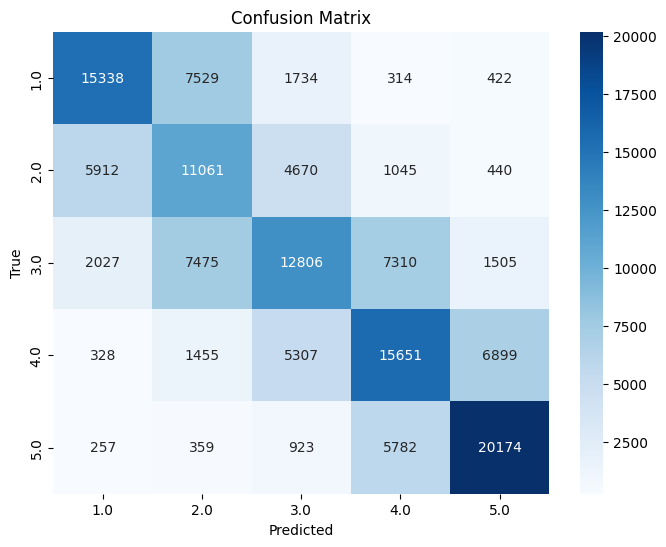

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---- 1. Get Predictions ----
y_pred_probs = model_a.predict(test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)

# ---- 2. Accuracy ----
test_accuracy = accuracy_score(test_labels, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# ---- 3. Classification Report ----
print("Classification Report:")
print(classification_report(test_labels, y_pred, target_names=[str(c) for c in label_encoder.classes_]))

# ---- 4. Confusion Matrix ----
cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[str(c) for c in label_encoder.classes_],
            yticklabels=[str(c) for c in label_encoder.classes_])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

save model

In [14]:
model_a.save("lstm_review_rating_model") 

INFO:tensorflow:Assets written to: lstm_review_rating_model\assets


INFO:tensorflow:Assets written to: lstm_review_rating_model\assets


 Save Tokenizer & Label Encoder

In [15]:
with open('tokenizer_lstm_f.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

joblib.dump(label_encoder, "label_encoder_lstm_f.pkl")

print("✅ Model A trained & saved successfully!")

✅ Model A trained & saved successfully!
